## Final Capstone Project Group
* Betsegaw T.	
* Mariamawet S.
* Miller T.
* Tesfaye H.

Objective

The goal of this project is to analyze patient demographic and medical data to identify key risk factors associated with stroke. Stroke is a major cause of death and long-term disability. Early prediction can help healthcare providers intervene before severe outcomes occur.

This project includes:

* Data Cleaning
* Exploratory Data Analysis (EDA)
* 5–7 Visualizations
* Modeling
* Insights Summary

In [485]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


pd.set_option("display.float_format", "{:.2f}".format)

In [486]:
df_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [487]:
df_data.size

61320

In [488]:
df_data.info

<bound method DataFrame.info of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male 67.00             0              1          Yes   
1     51676  Female 61.00             0              0          Yes   
2     31112    Male 80.00             0              1          Yes   
3     60182  Female 49.00             0              0          Yes   
4      1665  Female 79.00             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female 80.00             1              0          Yes   
5106  44873  Female 81.00             0              0          Yes   
5107  19723  Female 35.00             0              0          Yes   
5108  37544    Male 51.00             0              0          Yes   
5109  44679  Female 44.00             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban 

In [489]:
df_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.00,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.10,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.30,0.23,45.28,7.85,0.22
min,67.00,0.08,0.00,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.00,0.00,77.25,23.50,0.00
50%,36932.00,45.00,0.00,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.00,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.00,1.00,271.74,97.60,1.00


    Clean the dataset

Make a copy of the DS

Standardize column names

Remove 'id' column 

Handle missing values Remove duplicates

Basic validity checks



In [490]:
df=df_data.copy()

In [491]:
df.duplicated().sum()


np.int64(0)

In [492]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ", "_")

In [493]:
#df.drop(columns=["id"], inplace=True)


In [494]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [495]:
df.isna().sum().sort_values(ascending=False)

bmi                  201
id                     0
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

Handling Missing BMI Values

Median does represent the majority of the population in our DB. 

Using the median avoids unrealistic or impossible values.

The median is stable and not influenced by extreme BMI outliers.

In [496]:
df["bmi"]=df["bmi"].fillna(df["bmi"].median())

In [497]:
#check to ensure BMI is

df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [498]:
#validity check
#Age should be above 0
#bmi should be positive
#glucose should be positive
df = df[(df["age"] > 0) & (df["bmi"] > 0) & (df["avg_glucose_level"] > 0)]
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.00,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,51676,Female,61.00,0,0,Yes,Self-employed,Rural,202.21,28.10,never smoked,1
2,31112,Male,80.00,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,60182,Female,49.00,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,1665,Female,79.00,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1
5,56669,Male,81.00,0,0,Yes,Private,Urban,186.21,29.00,formerly smoked,1
6,53882,Male,74.00,1,1,Yes,Private,Rural,70.09,27.40,never smoked,1
7,10434,Female,69.00,0,0,No,Private,Urban,94.39,22.80,never smoked,1
8,27419,Female,59.00,0,0,Yes,Private,Rural,76.15,28.10,Unknown,1
9,60491,Female,78.00,0,0,Yes,Private,Urban,58.57,24.20,Unknown,1


1: Univariate Analysis will explore variables and show the distribution. 


C:\Users\mrmik\AppData\Local\Temp\ipykernel_61144\3831513633.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="bmi_category", palette="Set3", ax=axes[3])


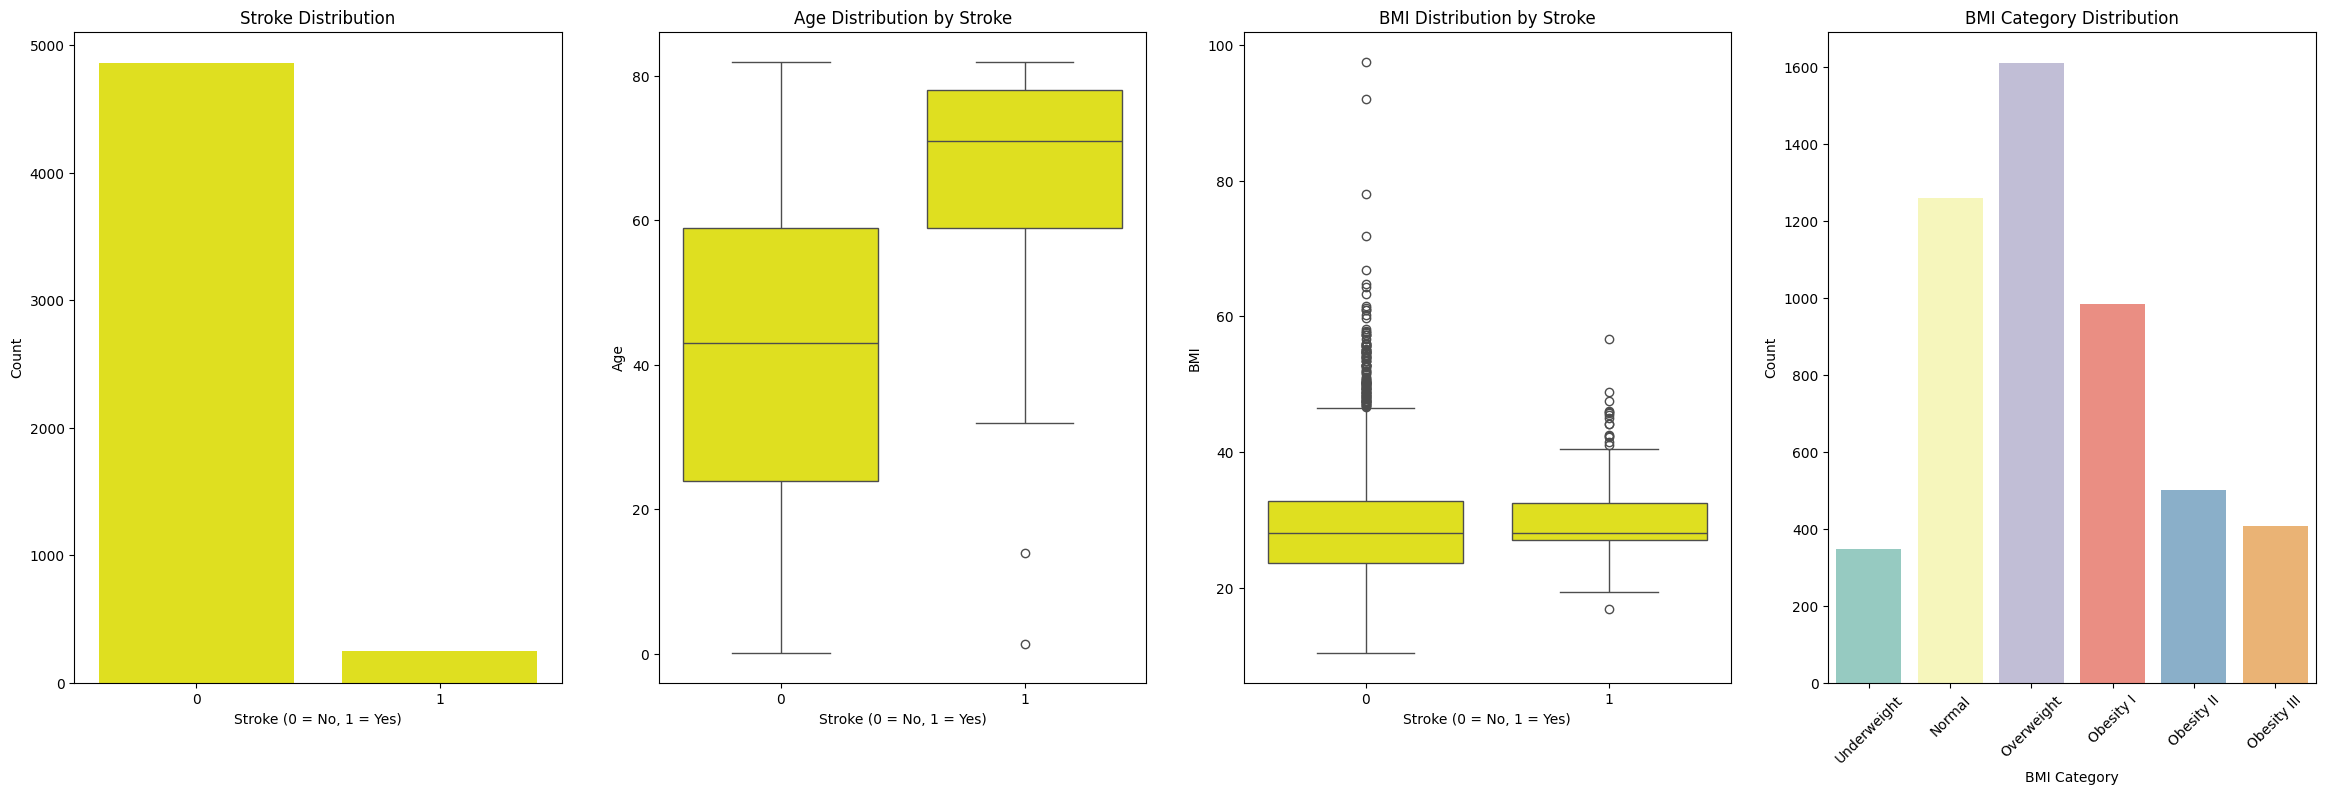

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

sns.countplot(x="stroke", data=df, color="yellow", ax=axes[0]) 
axes[0].set_title("Stroke Distribution") 
axes[0].set_xlabel("Stroke (0 = No, 1 = Yes)") 
axes[0].set_ylabel("Count")

sns.boxplot(x="stroke", y="age", data=df, color="yellow", ax=axes[1]) 
axes[1].set_title("Age Distribution by Stroke") 
axes[1].set_xlabel("Stroke (0 = No, 1 = Yes)") 
axes[1].set_ylabel("Age")

sns.boxplot(x="stroke", y="bmi", data=df, color="yellow", ax=axes[2]) 
axes[2].set_title("BMI Distribution by Stroke") 
axes[2].set_xlabel("Stroke (0 = No, 1 = Yes)") 
axes[2].set_ylabel("BMI") 
plt.tight_layout(pad=3)

bins = [0, 18.5, 25, 30, 35, 40, 100] 
labels = ["Underweight", "Normal", "Overweight", "Obesity I", "Obesity II", "Obesity III"] 
df["bmi_category"] = pd.cut( df["bmi"], bins=bins, labels=labels, include_lowest=True )

sns.countplot(data=df, x="bmi_category", palette="Set3", ax=axes[3]) 
axes[3].set_title("BMI Category Distribution") 
axes[3].set_xlabel("BMI Category") 
axes[3].set_ylabel("Count") 
axes[3].tick_params(axis='x', rotation=45)


 * Stroke cases are rare compared to non‑stroke cases.

 *  Individuals who experienced a stroke tend to be significantly older.

 * The BMI boxplot shows overlapping distributions with no major shift between stroke and non‑stroke individuals.

 * Overweight and Obesity I are the most common BMI categories.

        BMI DISTRIBUTION BY STROKE OUTLIERS
* The glucose variable contains several high‑value outliers.

* These outliers are medically plausible and represent individuals with elevated glucose levels.

* Since high glucose is a known stroke risk factor, the outliers provide meaningful information.

* Therefore, they are kept in the dataset but acknowledged in the analysis.

2.1 Bivariate anaylsis: Medical Risk Factors These show how medical conditions relate to stroke.


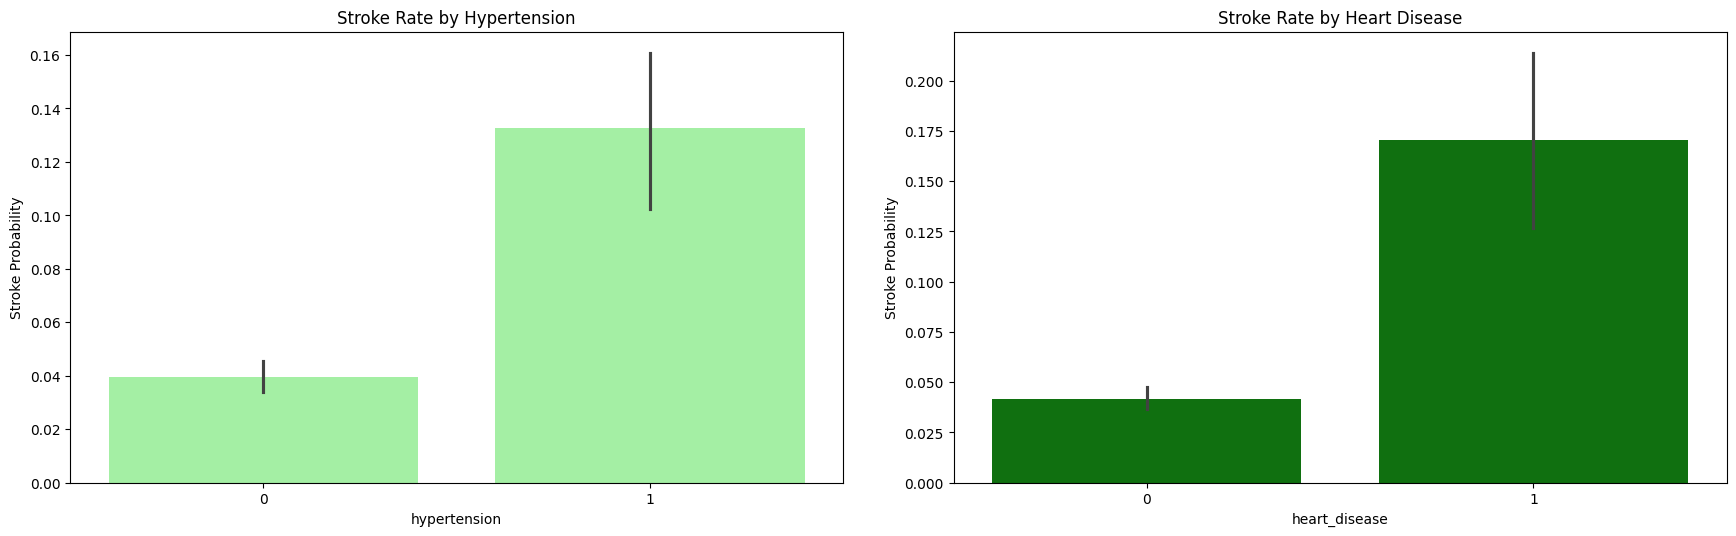

In [500]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x="hypertension", y="stroke", data=df, color="palegreen", ax=axes[0]) 
axes[0].set_title("Stroke Rate by Hypertension") 
axes[0].set_ylabel("Stroke Probability")

sns.barplot(x="heart_disease", y="stroke", data=df, color="green",ax=axes[1])
axes[1].set_title("Stroke Rate by Heart Disease")
axes[1].set_ylabel("Stroke Probability")



plt.tight_layout(pad=3.0)


* The bar for higher hypertension is noticeably taller than hypertension = 0. This shows that high blood pressure is a meaningful contributor to stroke risk in your dataset.

*  individuals with heart disease have a higher stroke probability than those without it. 

2.2 Bivariate anaylisis: These show how life style choice  relate to stroke.

C:\Users\mrmik\AppData\Local\Temp\ipykernel_61144\699293590.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_glucose = smoker_df.groupby('age_group')[['avg_glucose_level', 'stroke']].mean()


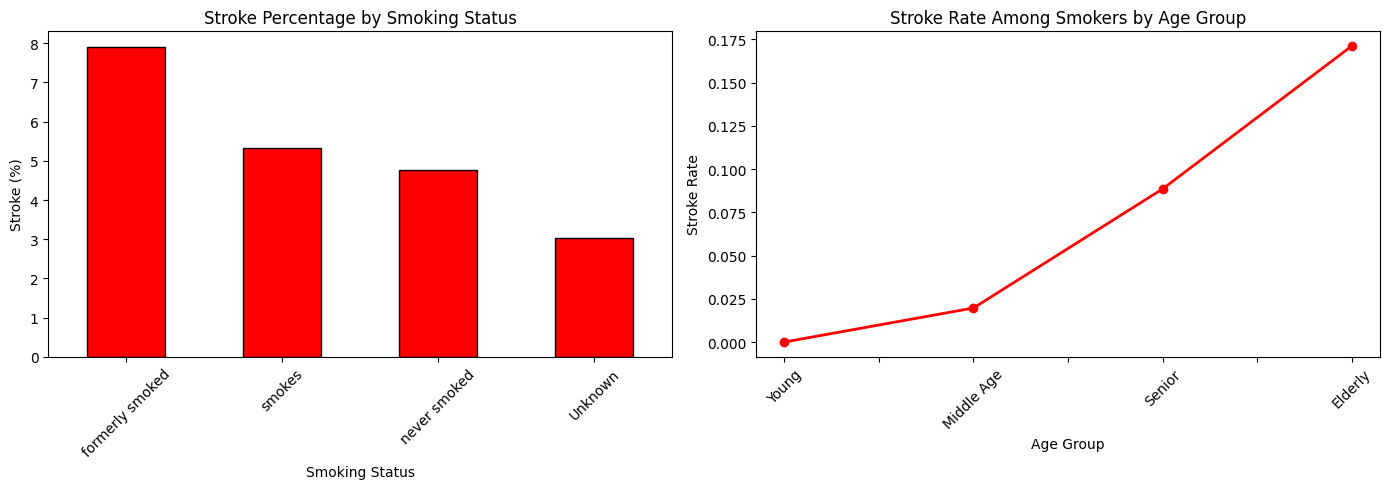

In [501]:
df['age_group'] = pd.cut( df['age'], bins=[0, 30, 50, 70, 100], labels=['Young', 'Middle Age', 'Senior', 'Elderly'] )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

smoking_stroke = df.groupby('smoking_status')['stroke'].mean() * 100
smoking_stroke = smoking_stroke.sort_values(ascending=False)
smoking_stroke.plot(kind='bar', ax=axes[0], color='red', edgecolor='black')
axes[0].set_title('Stroke Percentage by Smoking Status')
axes[0].set_xlabel('Smoking Status')
axes[0].set_ylabel('Stroke (%)')
axes[0].tick_params(axis='x', rotation=45)

smoker_df = df[df['smoking_status'] == 'smokes']
age_glucose = smoker_df.groupby('age_group')[['avg_glucose_level', 'stroke']].mean()
age_glucose['stroke'].plot(kind='line', marker='o', ax=axes[1], color='red', linewidth=2)
axes[1].set_title('Stroke Rate Among Smokers by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Stroke Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()




* Former smokers have the highest stroke probability of all smoking groups

* Current smokers also show elevated stroke risk compared to those that never smoked 

* Stroke risk among smokers increases sharply with age

2.3 Bivariate Visuals (2 plots) compare stroke to age‑based categories.



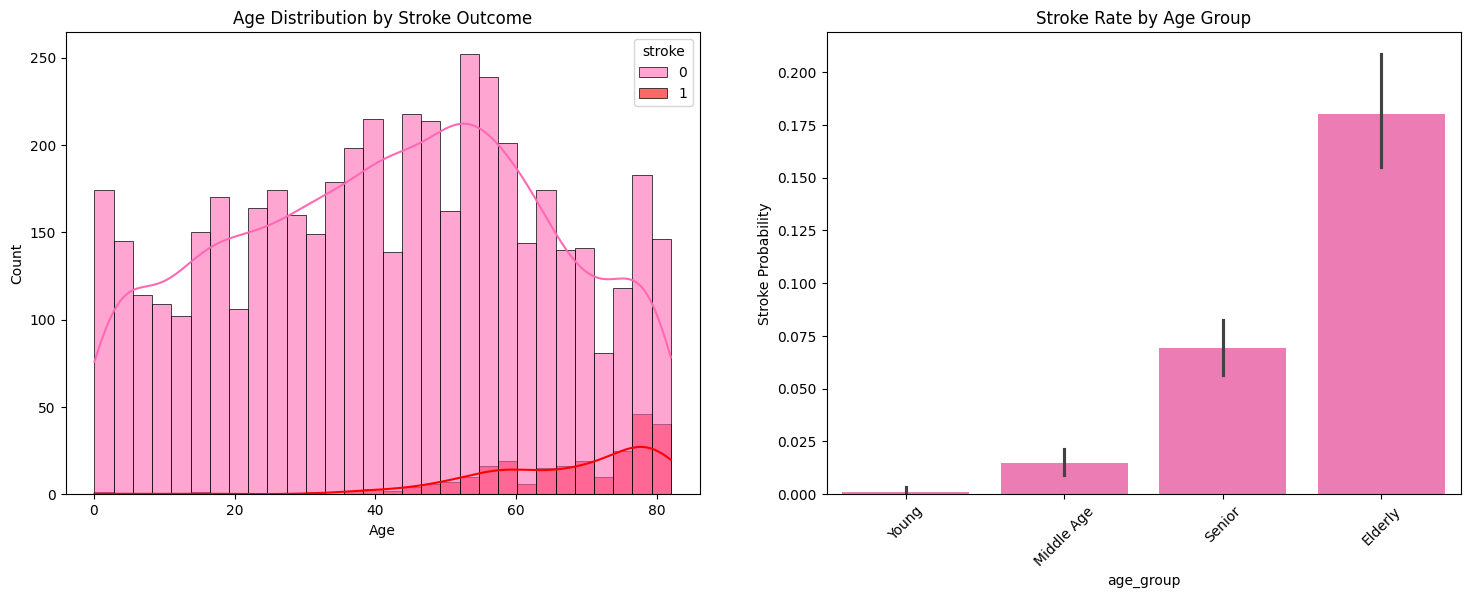

In [502]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))



sns.histplot(data=df, x="age", hue="stroke", bins=30, kde=True, palette={0: "hotpink", 1: "red"}, alpha=0.6, edgecolor='black', ax=axes[0],linewidth=0.5) 
axes[0].set_title("Age Distribution by Stroke Outcome") 
axes[0].set_xlabel("Age") 
axes[0].set_ylabel("Count")


df["age_group"] = pd.cut( df["age"], bins=[0, 30, 50, 70, 100], labels=["Young", "Middle Age", "Senior", "Elderly"] ) 
sns.barplot(x="age_group", y="stroke", data=df, color="hotpink", ax=axes[1]) 
axes[1].set_title("Stroke Rate by Age Group") 
axes[1].set_ylabel("Stroke Probability") 
axes[1].tick_params(axis='x', rotation=45)



* Stroke cases are heavily concentrated in older age ranges

* Stroke probability increases sharply across age groups

* Younger individuals rarely experience stroke, regardless of population size

* The Elderly group has the highest stroke probability by a wide margin suggesting that the combination of vascular aging, chronic conditions, and accumulated risk factors makes this group the most vulnerable.
 

2.4 MULTIVARIATE ANALYSIS (2) clear medical insight and analytical insight



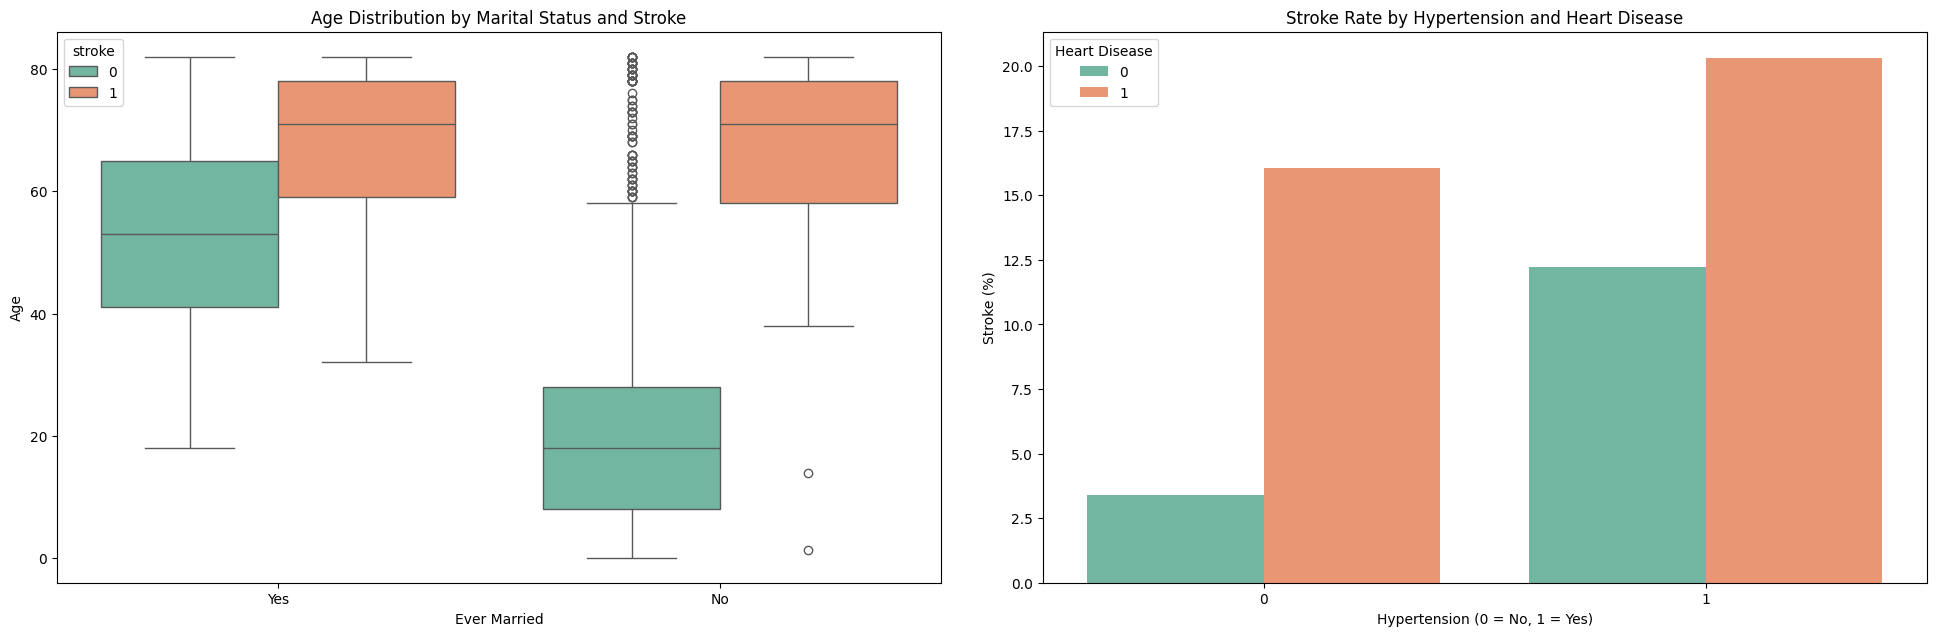

In [503]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.boxplot( data=df, x="ever_married", y="age", hue="stroke", palette="Set2", ax=axes[0] ) 
axes[0].set_title("Age Distribution by Marital Status and Stroke") 
axes[0].set_xlabel("Ever Married") 
axes[0].set_ylabel("Age")  

medical_factor = df.groupby(["hypertension", "heart_disease"])["stroke"].mean() * 100 
medical_factor = medical_factor.reset_index() 
sns.barplot( data=medical_factor, x="hypertension", y="stroke", hue="heart_disease", palette="Set2", ax=axes[1] ) 
axes[1].set_title("Stroke Rate by Hypertension and Heart Disease") 
axes[1].set_xlabel("Hypertension (0 = No, 1 = Yes)") 
axes[1].set_ylabel("Stroke (%)")
axes[1].legend(title="Heart Disease") 
plt.tight_layout(pad=3)




* The stroke rate climbs highest when both Hypertension and Heart disease are present.

        * This is clinically meaningful because:

* Hypertension stresses blood vessels.

* Heart disease weakens cardiovascular function.

* Together, they create a high‑risk environment for stroke.

* People who had a stroke are much older on average  in both married and unmarried groups

* .Married individuals tend to be older, and older individuals have higher stroke rates.

* Younger individuals rarely appear in the stroke group

2.5 Correlation analysis showing relationship between numerical predictors

Text(0.5, 1.0, 'Correlation Between Strong Predictors and Stroke')

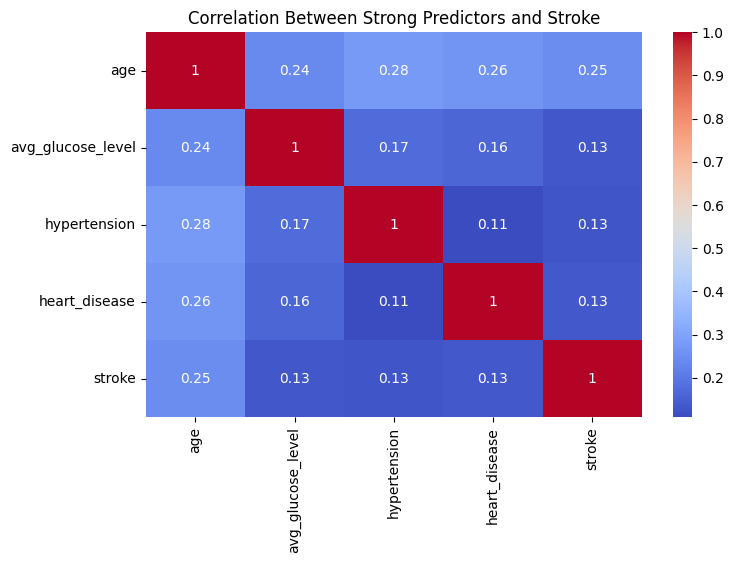

In [504]:
strong_correlation = ["age", "avg_glucose_level", "hypertension", "heart_disease", "stroke"] 
plt.figure(figsize=(8,5)) 
sns.heatmap(df[strong_correlation].corr(), cmap="coolwarm", annot=True) 
plt.title("Correlation Between Strong Predictors and Stroke")

 key correlations from our data sets are
 
* Age → Strongest positive correlation with stroke

* Hypertension → Moderate positive correlation

* Heart Disease → Moderate positive correlation

* Avg Glucose Level → Weak to moderate correlation

* BMI → Very weak correlation

Major Insights

* Age is the strongest predictor of stroke.

* Patients with hypertension are significantly more likely to have stroke.

* Heart disease increases stroke risk. 

* Higher average glucose levels are observed among stroke patients.

* High glucose levels show moderate relationship.

Healthcare Recommendations

* Prioritize stroke screening for elderly patients.

* Monitor and manage hypertension aggressively.

* Control blood glucose levels in high-risk patients.

* Promote heart disease prevention programs.

 Final Summary 

Stroke risk in this dataset is driven mainly by age, hypertension, heart disease, smoking history, and elevated glucose levels. Older 

adults and individuals with cardiovascular or metabolic conditions show the highest stroke probabilities. In contrast, several demographic 

factors—including gender, work type, residence type, and BMI—showed little to no impact on stroke outcomes, with similar distributions 

between stroke and non‑stroke groups. Overall, the strongest predictors are medical and age‑related, while most demographic variables do 

not meaningfully influence stroke risk.